<img width="800px" src="../fidle/img/header.svg"></img>

# <!-- TITLE --> [KMNIST1] - Simple classification with DNN
<!-- DESC --> An example of classification using a dense neural network for the famous MNIST dataset
<!-- AUTHOR : Jean-Luc Parouty (CNRS/SIMaP) -->

## Objectives :
 - Recognizing handwritten numbers
 - Understanding the principle of a classifier DNN network 
 - Implementation with Keras 


The [MNIST dataset](http://yann.lecun.com/exdb/mnist/) (Modified National Institute of Standards and Technology) is a must for Deep Learning.  
It consists of 60,000 small images of handwritten numbers for learning and 10,000 for testing.


## What we're going to do :

 - Retrieve data
 - Preparing the data
 - Create a model
 - Train the model
 - Evaluate the result


## Step 1 - Init python stuff

In [1]:
# import os
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras

import numpy as np
import matplotlib.pyplot as plt
import sys,os
from importlib import reload

# Init Fidle environment
#import fidle

#run_id, run_dir, datasets_dir = fidle.init('MNIST1')

C:\Users\Kered\AppData\Roaming\Python\Python38\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Verbosity during training : 0 = silent, 1 = progress bar, 2 = one line per epoch

In [ ]:
#fit_verbosity = 1

Override parameters (batch mode) - Just forget this cell

In [ ]:
#fidle.override('fit_verbosity')

## Step 2 - Retrieve data
MNIST is one of the most famous historic dataset.  
Include in [Keras datasets](https://www.tensorflow.org/api_docs/python/tf/keras/datasets)

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train : ",x_train.shape)
print("y_train : ",y_train.shape)
print("x_test  : ",x_test.shape)
print("y_test  : ",y_test.shape)

x_train :  (60000, 28, 28)
y_train :  (60000,)
x_test  :  (10000, 28, 28)
y_test  :  (10000,)


## Step 3 - Preparing the data

In [3]:
print('Before normalization : Min={}, max={}'.format(x_train.min(),x_train.max()))

xmax=x_train.max()
x_train = x_train / xmax
x_test  = x_test  / xmax

print('After normalization  : Min={}, max={}'.format(x_train.min(),x_train.max()))

Before normalization : Min=0, max=255
After normalization  : Min=0.0, max=1.0


### Have a look

In [ ]:
# fidle.scrawler.images(x_train, y_train, [27],  x_size=5,y_size=5, colorbar=True, save_as='01-one-digit')
# fidle.scrawler.images(x_train, y_train, range(5,41), columns=12, save_as='02-many-digits')

## Step 4 - Create model
About informations about : 
 - [Optimizer](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers)
 - [Activation](https://www.tensorflow.org/api_docs/python/tf/keras/activations)
 - [Loss](https://www.tensorflow.org/api_docs/python/tf/keras/losses)
 - [Metrics](https://www.tensorflow.org/api_docs/python/tf/keras/metrics)

In [4]:
hidden1     = 100
hidden2     = 100

model = keras.Sequential([
    keras.layers.Input((28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense( hidden1, activation='relu'),
    keras.layers.Dense( hidden2, activation='relu'),
    keras.layers.Dense( 10,      activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## Step 5 - Train the model

In [6]:
batch_size  = 512
epochs      =  16

history = model.fit(  x_train, y_train,
                      batch_size      = batch_size,
                      epochs          = epochs,
                      verbose         = 2,
                      validation_data = (x_test, y_test))

Epoch 1/16
118/118 - 1s - loss: 0.5758 - accuracy: 0.8422 - val_loss: 0.2476 - val_accuracy: 0.9297 - 1s/epoch - 12ms/step
Epoch 2/16
118/118 - 1s - loss: 0.2203 - accuracy: 0.9369 - val_loss: 0.1944 - val_accuracy: 0.9416 - 638ms/epoch - 5ms/step
Epoch 3/16
118/118 - 1s - loss: 0.1673 - accuracy: 0.9519 - val_loss: 0.1469 - val_accuracy: 0.9565 - 697ms/epoch - 6ms/step
Epoch 4/16
118/118 - 1s - loss: 0.1342 - accuracy: 0.9610 - val_loss: 0.1286 - val_accuracy: 0.9616 - 734ms/epoch - 6ms/step
Epoch 5/16
118/118 - 1s - loss: 0.1125 - accuracy: 0.9675 - val_loss: 0.1140 - val_accuracy: 0.9662 - 719ms/epoch - 6ms/step
Epoch 6/16
118/118 - 1s - loss: 0.0957 - accuracy: 0.9718 - val_loss: 0.1016 - val_accuracy: 0.9704 - 741ms/epoch - 6ms/step
Epoch 7/16
118/118 - 1s - loss: 0.0834 - accuracy: 0.9752 - val_loss: 0.1024 - val_accuracy: 0.9699 - 717ms/epoch - 6ms/step
Epoch 8/16
118/118 - 1s - loss: 0.0712 - accuracy: 0.9792 - val_loss: 0.0948 - val_accuracy: 0.9716 - 715ms/epoch - 6ms/step
Ep

## Step 6 - Evaluate
### 6.1 - Final loss and accuracy

In [7]:
score = model.evaluate(x_test, y_test, verbose=0)

print('Test loss     :', score[0])
print('Test accuracy :', score[1])

Test loss     : 0.07953109592199326
Test accuracy : 0.9769999980926514


### 6.2 - Plot history

Text(0.5, 1.0, 'Training and validation loss')

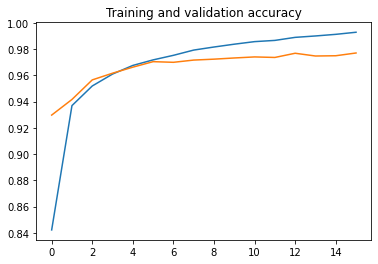

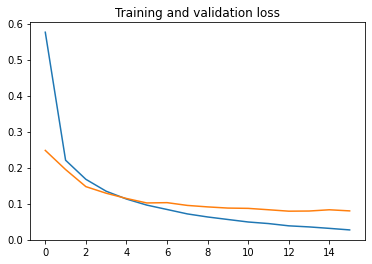

In [9]:
acc      = history.history[     'accuracy' ]
val_acc  = history.history[ 'val_accuracy' ]
loss     = history.history[    'loss' ]
val_loss = history.history['val_loss' ]

epochs   = range(len(acc)) # Get number of epochs

#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot  ( epochs,     acc )
plt.plot  ( epochs, val_acc )
plt.title ('Training and validation accuracy')
plt.figure()

#------------------------------------------------
# Plot training and validation loss per epoch
#------------------------------------------------
plt.plot  ( epochs,     loss )
plt.plot  ( epochs, val_loss )
plt.title ('Training and validation loss'   )

In [10]:
# fidle.scrawler.history(history, figsize=(6,4), save_as='03-history')

### 6.3 - Plot results

In [14]:
#y_pred   = model.predict_classes(x_test)           Deprecated after 01/01/2021 !!

y_sigmoid = model.predict(x_test)
y_pred    = np.argmax(y_sigmoid, axis=-1)



In [20]:
from sklearn.metrics import confusion_matrix
fig = plt.figure(figsize=(10, 10)) # Set Figure

y_pred = model.predict(x_test) # Predict class probabilities as 2 => [0.1, 0, 0.9, 0, 0, 0, 0, 0, 0, 0]

Y_pred = np.argmax(y_pred, axis=-1) # Decode Predicted labels
Y_test = np.argmax(y_test, axis=-1) # Decode labels

mat = confusion_matrix(Y_test, Y_pred) # Confusion matrix

# Plot Confusion matrix
sns.heatmap(mat.T, square=True, annot=True, cbar=False, cmap=plt.cm.Blues, fmt='.0f')
plt.xlabel('Predicted Values')
plt.ylabel('True Values');
plt.show();

TypeError: Singleton array 7 cannot be considered a valid collection.

<Figure size 720x720 with 0 Axes>

### 6.4 - Plot some errors

In [ ]:
errors=[ i for i in range(len(x_test)) if y_pred[i]!=y_test[i] ]
errors=errors[:min(24,len(errors))]
fidle.scrawler.images(x_test, y_test, errors[:15], columns=6, x_size=2, y_size=2, y_pred=y_pred, save_as='05-some-errors')

In [ ]:
fidle.scrawler.confusion_matrix(y_test,y_pred,range(10),normalize=True, save_as='06-confusion-matrix')

In [ ]:
fidle.end()

<div class="todo">
    A few things you can do for fun:
    <ul>
        <li>Changing the network architecture (layers, number of neurons, etc.)</li>
        <li>Display a summary of the network</li>
        <li>Retrieve and display the softmax output of the network, to evaluate its "doubts".</li>
    </ul>
</div>

---
<img width="80px" src="../fidle/img/logo-paysage.svg"></img>